IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

LOAD DATASET

In [3]:
df=pd.read_csv("Fraud_Analysis_Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [6]:
df.shape

(11142, 10)

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style="whitegrid")

### Transaction Type Distribution

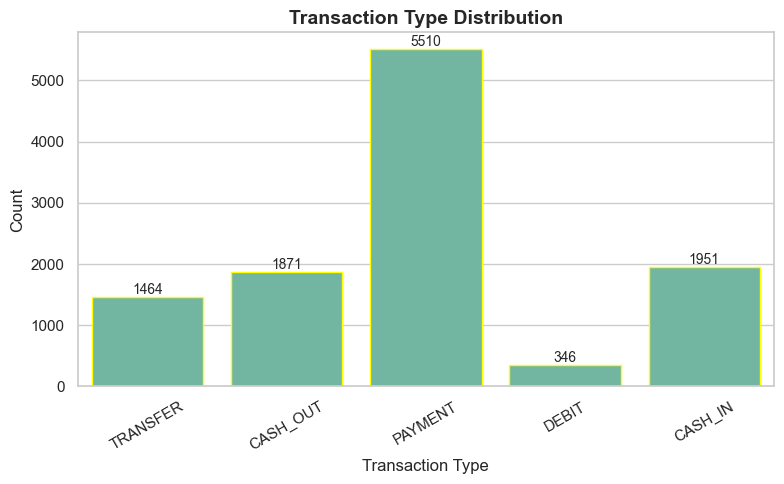

In [12]:
sns.set_theme(style="whitegrid", palette="Set2")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="type",
    edgecolor="yellow"
)

# Titles and labels
ax.set_title("Transaction Type Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Transaction Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Rotate x labels if needed
plt.xticks(rotation=30)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

### Fraud VS Non-Fraud Transactions

C:\Users\acer\AppData\Local\Temp\ipykernel_9468\3082396038.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


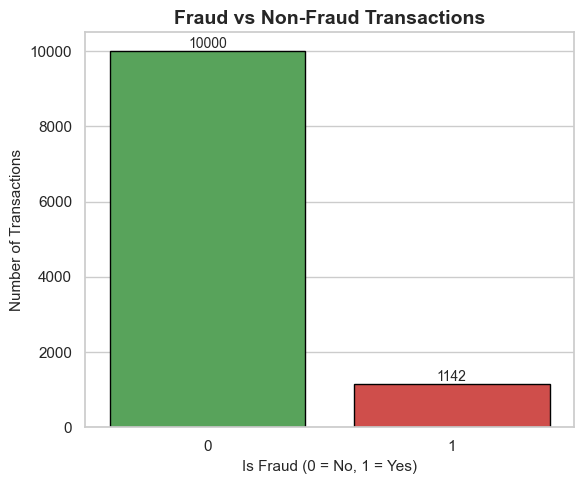

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="isFraud",
    palette={'0': "#4CAF50", '1': "#E53935"},
    edgecolor="black"
)


# Titles & labels
ax.set_title("Fraud vs Non-Fraud Transactions", fontsize=14, fontweight="bold")
ax.set_xlabel("Is Fraud (0 = No, 1 = Yes)", fontsize=11)
ax.set_ylabel("Number of Transactions", fontsize=11)

# Add count labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

### Fraud Percentage Distribution

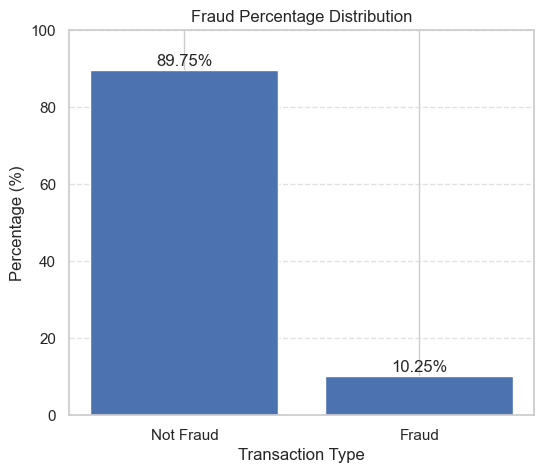

In [14]:
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

labels = ['Not Fraud', 'Fraud']
values = fraud_pct.values

plt.figure(figsize=(6,5))
plt.bar(labels, values)

plt.xlabel("Transaction Type")
plt.ylabel("Percentage (%)")
plt.title("Fraud Percentage Distribution")

plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show value on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()



### Fraud By Transaction Type

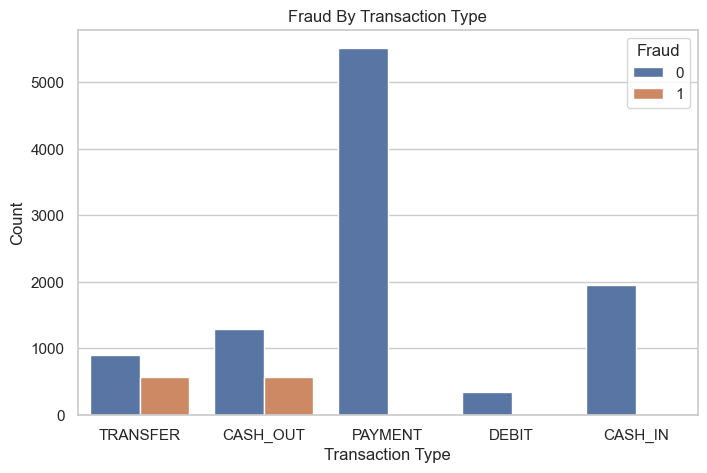

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud By Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(title="Fraud")
plt.show()

### Fraud Transactions Over Time

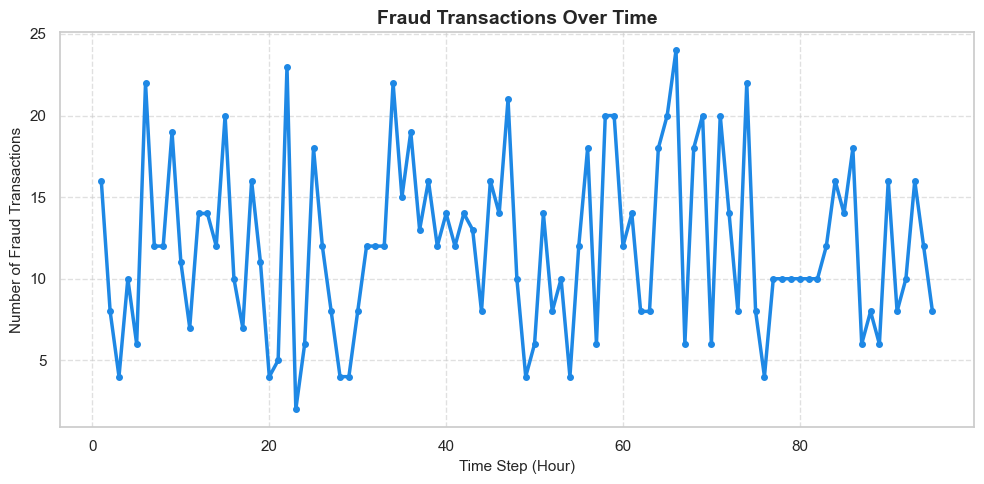

In [16]:
# Prepare data
fraud_time = df[df["isFraud"] == 1].groupby("step").size()

# Styling
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

plt.plot(
    fraud_time.index,
    fraud_time.values,
    linewidth=2.5,
    color="#1E88E5",
    marker="o",
    markersize=4
)

# Titles & labels
plt.title("Fraud Transactions Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Time Step (Hour)", fontsize=11)
plt.ylabel("Number of Fraud Transactions", fontsize=11)

# Grid styling
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### Fraud Distribution Over Time Step(Hours)

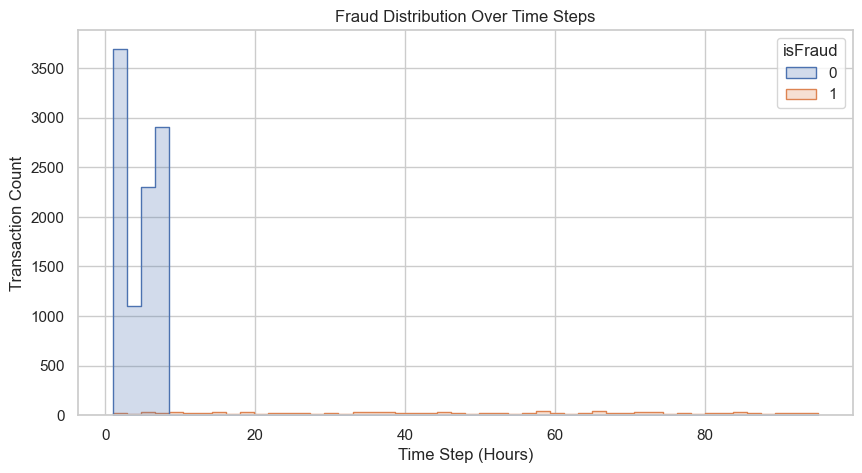

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='step',
    hue='isFraud',
    bins=50,
    element='step'
)
plt.title("Fraud Distribution Over Time Steps")
plt.xlabel("Time Step (Hours)")
plt.ylabel("Transaction Count")
plt.show()

### Correlation Heatmap

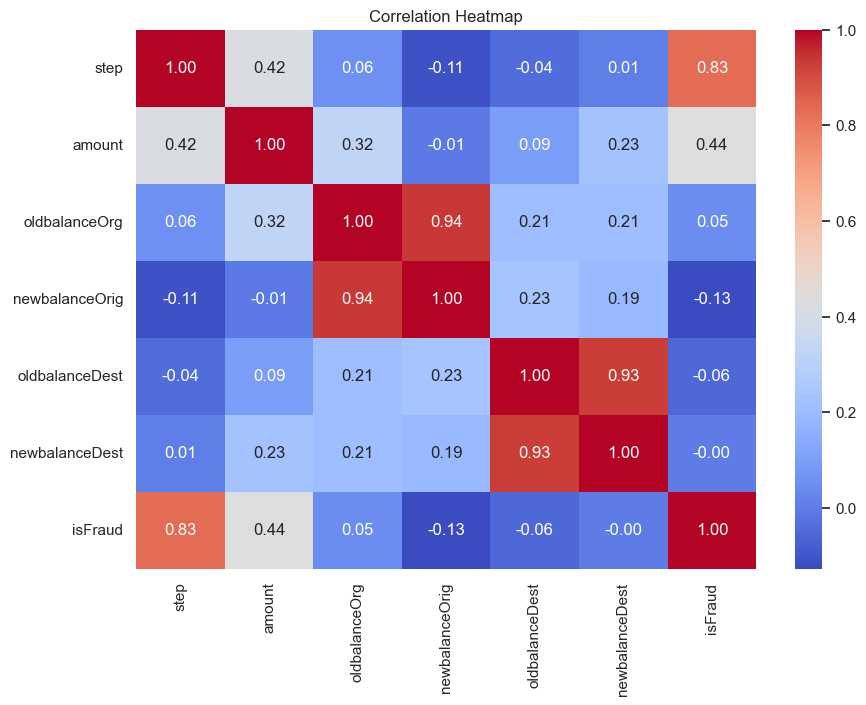

In [18]:
plt.figure(figsize=(10,7))
corr = df[['step','amount','oldbalanceOrg','newbalanceOrig',
           'oldbalanceDest','newbalanceDest','isFraud']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

In [19]:
df.drop(columns=["nameOrig", "nameDest"], inplace=True)

In [20]:
df['isFraud'].value_counts()
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    89.750494
1    10.249506
Name: proportion, dtype: float64

In [21]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1


### Model Training

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
numeric_features = ['step','amount','oldbalanceOrg','newbalanceOrig',
                    'oldbalanceDest','newbalanceDest']

categorical_features = ['type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [28]:
for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    
    print("="*60)
    print(name)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2001
           1       0.90      0.96      0.93       228

    accuracy                           0.98      2229
   macro avg       0.95      0.97      0.96      2229
weighted avg       0.98      0.98      0.98      2229

ROC-AUC: 0.994789885758875
Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.96      0.98       228

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.999970409532076
Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.0

In [29]:
final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
sample = X_test.iloc[[0]]

pred = final_pipeline.predict(sample)[0]
prob = final_pipeline.predict_proba(sample)[0][1]

print("Prediction:", "Fraud" if pred == 1 else "Legitimate")
print("Fraud Probability:", round(prob*100,2), "%")

Prediction: Legitimate
Fraud Probability: 0.0 %


In [31]:
def print_prediction(pipeline, data):
    pred = pipeline.predict(data)[0]
    prob = pipeline.predict_proba(data)[0][1]

    print("===================================")
    print("Transaction Details:")
    display(data)
    
    print("\nPrediction Result:")
    print("Status :", "🚨 FRAUD" if pred == 1 else "✅ NOT FRAUD")
    print("Fraud Probability :", f"{prob*100:.2f}%")
    print("===================================\n")

In [32]:
fraud_txn = pd.DataFrame([{
    'step': 350,
    'type': 'TRANSFER',
    'amount': 850000,
    'oldbalanceOrg': 900000,
    'newbalanceOrig': 50000,
    'oldbalanceDest': 0,
    'newbalanceDest': 0
}])

print_prediction(final_pipeline, fraud_txn)

Transaction Details:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,350,TRANSFER,850000,900000,50000,0,0



Prediction Result:
Status : 🚨 FRAUD
Fraud Probability : 76.33%



In [33]:
non_fraud_txn = pd.DataFrame([{
    'step': 120,
    'type': 'PAYMENT',
    'amount': 2500,
    'oldbalanceOrg': 15000,
    'newbalanceOrig': 12500,
    'oldbalanceDest': 30000,
    'newbalanceDest': 32500
}])

print_prediction(final_pipeline, non_fraud_txn)

Transaction Details:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,120,PAYMENT,2500,15000,12500,30000,32500



Prediction Result:
Status : ✅ NOT FRAUD
Fraud Probability : 48.33%



In [34]:
temp_txn = pd.DataFrame([{
    'step': 200,
    'type': 'TRANSFER',
    'amount': 20000,
    'oldbalanceOrg': 80000,
    'newbalanceOrig': 60000,
    'oldbalanceDest': 20000,
    'newbalanceDest': 40000
}])

print_prediction(final_pipeline, temp_txn)

Transaction Details:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,200,TRANSFER,20000,80000,60000,20000,40000



Prediction Result:
Status : 🚨 FRAUD
Fraud Probability : 66.00%



In [35]:
#Feature	Meaning
#step	= Time step of transaction
#type	= Transaction type (PAYMENT, TRANSFER, CASH_OUT)
#amount	= Transaction amount
#oldbalanceOrg	= Sender’s balance before transaction
#newbalanceOrig	= Sender’s balance after transaction
#oldbalanceDest	= Receiver’s balance before transaction
#newbalanceDest	= Receiver’s balance after transaction

In [36]:
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<Figure size 600x500 with 0 Axes>

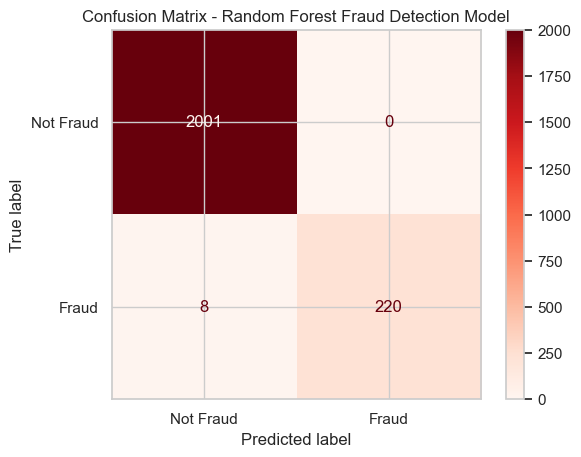

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions on test data
y_test_pred = final_pipeline.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Reds", values_format='d')   # color = Reds, numbers = integer
plt.title("Confusion Matrix - Random Forest Fraud Detection Model")
plt.show()


- The model misses very few fraud cases, which means it is able to catch most fraudulent transactions.

- It does not wrongly flag any genuine transactions as fraud, so real customers are not disturbed. This is important for maintaining customer trust.

- The Random Forest model performs very well on this dataset because it can learn complex patterns in the data.

- Overall, the model shows high accuracy, catches most fraud cases, and avoids false alarms, making it a good choice for fraud detection in this project.

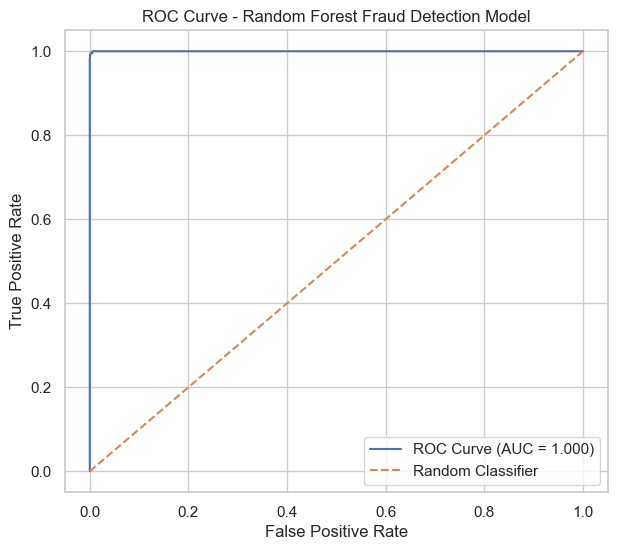

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Fraud Detection Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



## 📈 ROC–AUC Curve

The ROC–AUC curve shows how well the model separates fraud from non-fraud transactions.  
A high ROC–AUC value indicates excellent model performance and strong classification ability.

In [40]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, final_pipeline.predict_proba(X_test)[:, 1])

0.9999671217023067

In [41]:
y_test.value_counts(normalize=True)

isFraud
0    0.897712
1    0.102288
Name: proportion, dtype: float64

In [42]:
df.head()
df.shape

(11142, 8)